In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob
from scipy import signal
import seaborn as sns

In [2]:
# dask
import dask
import dask.array as da
import distributed
from dask.distributed import Client

client = Client()
client

/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38385 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:38385/status,
Dashboard: http://127.0.0.1:38385/status,Workers: 8
Total threads: 32,Total memory: 35.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34973,Workers: 0
Dashboard: http://127.0.0.1:38385/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46497,Total threads: 4
Dashboard: http://127.0.0.1:35277/status,Memory: 4.38 GiB
Nanny: tcp://127.0.0.1:43897,


In [6]:
path_atm_22 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251125_pinatubo10Tg22_e01/atm/hist"
ds_22 = xr.open_mfdataset(f"{path_atm_22}/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [7]:
path_atm_19_c =  "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20260116_pinatubo10tg_19_c/atm/hist"
ds_19_c = xr.open_mfdataset(f"{path_atm_19_c}/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02.cam.h0.*.nc", combine="by_coords", parallel=True)

In [8]:
path_atm_24 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251129_pinatubo17Tg24_e01/atm/hist"
ds_24 = xr.open_mfdataset(f"{path_atm_24}/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [9]:
path_atm_1825 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251204_pinatubo10Tg18_25_e01/atm/hist"
ds_1825 = xr.open_mfdataset(f"{path_atm_1825}/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [10]:
path_atm_1825_17tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251207_pinatubo17Tg18_25_e01/atm/hist"
ds_1825_17tg = xr.open_mfdataset(f"{path_atm_1825_17tg}/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [11]:
path_atm_1tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251210_pinatubo1Tg19_e01/atm/hist"
ds_1tg = xr.open_mfdataset(f"{path_atm_1tg}/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [12]:
path_atm_1pr = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251223_pinatubo10Tg_1pr/atm/hist"
ds_1pr = xr.open_mfdataset(f"{path_atm_1pr}/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr.cam.h0.*.nc", combine="by_coords", parallel=True)

In [13]:
path_atm_60tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20260108_pinatubo60Tg19_e01/atm/hist"
ds_60tg = xr.open_mfdataset(f"{path_atm_60tg}/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19.cam.h0.*.nc", combine="by_coords", parallel=True)

In [14]:
client.close()

In [15]:
def shift_one_month_back(t):
    if t.month == 1:
        return cftime.DatetimeNoLeap(t.year - 1, 12, t.day, t.hour, t.minute, t.second)
    else:
        return cftime.DatetimeNoLeap(t.year, t.month - 1, t.day, t.hour, t.minute, t.second)

shifted_time = np.array([shift_one_month_back(t) for t in ds_22['time'].values])
ds_22 = ds_22.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19_c['time'].values])
ds_19_c = ds_19_c.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_24['time'].values])
ds_24 = ds_24.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825['time'].values])
ds_1825 = ds_1825.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825_17tg['time'].values])
ds_1825_17tg = ds_1825_17tg.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1tg['time'].values])
ds_1tg = ds_1tg.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1pr['time'].values])
ds_1pr = ds_1pr.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_60tg['time'].values])
ds_60tg = ds_60tg.assign_coords(time=shifted_time)

In [16]:
lat_22 = ds_22["lat"]
weighted_lat_22 = np.cos(np.deg2rad(lat_22))
lat_19_c = ds_19_c["lat"]
weighted_lat_19_c = np.cos(np.deg2rad(lat_19_c))
lat_24 = ds_24["lat"]
weighted_lat_24 = np.cos(np.deg2rad(lat_24))
lat_1825 = ds_1825["lat"]
weighted_lat_1825 = np.cos(np.deg2rad(lat_1825))
lat_1825_17tg = ds_1825_17tg["lat"]
weighted_lat_1825_17tg = np.cos(np.deg2rad(lat_1825_17tg))
lat_1tg = ds_1tg["lat"]
weighted_lat_1tg = np.cos(np.deg2rad(lat_1tg))
lat_1pr = ds_1pr["lat"]
weighted_lat_1pr = np.cos(np.deg2rad(lat_1pr))
lat_60tg = ds_60tg["lat"]
weighted_lat_60tg = np.cos(np.deg2rad(lat_60tg))

In [17]:
# Getting the SO2 first

Ms = 32.065 
Mair = 28.96  # dry air
Matmos = 5.3 * 10**21
K = (Ms/Mair) * Matmos *10**(-12)

so2_19_c = ds_19_c["SO2"].weighted(weighted_lat_19_c).mean(dim=["lev", "lat", "lon"]) * K
so2_19_c_max = max(so2_19_c)
so2_19_c_max.values

array(8.80449907)

/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarn

In [18]:
so2_60tg = ds_60tg["SO2"].weighted(weighted_lat_60tg).mean(dim=["lev", "lat", "lon"]) * K
so2_60tg_max = max(so2_60tg)
so2_22 = ds_22["SO2"].weighted(weighted_lat_22).mean(dim=["lev", "lat", "lon"]) * K
so2_22_max = max(so2_22)
so2_24 = ds_24["SO2"].weighted(weighted_lat_24).mean(dim=["lev", "lat", "lon"]) * K
so2_24_max = max(so2_24)
so2_1825 = ds_1825["SO2"].weighted(weighted_lat_1825).mean(dim=["lev", "lat", "lon"]) * K
so2_1825_max = max(so2_1825)
so2_1825_17tg = ds_1825_17tg["SO2"].weighted(weighted_lat_1825_17tg).mean(dim=["lev", "lat", "lon"]) * K
so2_1825_17tg_max = max(so2_1825_17tg)
so2_1tg = ds_1tg["SO2"].weighted(weighted_lat_1tg).mean(dim=["lev", "lat", "lon"]) * K
so2_1tg_max = max(so2_1tg)
so2_1pr = ds_1pr["SO2"].weighted(weighted_lat_1pr).mean(dim=["lev", "lat", "lon"]) * K
so2_1pr_max = max(so2_1pr)

In [19]:
"""ts_aod = ds_19[aod500].weighted(weighted_lat).mean(dim=["lat", "lon"])
daylight_monthly = ds_19[daylight].weighted(weighted_lat).mean(dim=["lat", "lon"])
ts_aod = ts_aod / daylight_monthly"""

'ts_aod = ds_19[aod500].weighted(weighted_lat).mean(dim=["lat", "lon"])\ndaylight_monthly = ds_19[daylight].weighted(weighted_lat).mean(dim=["lat", "lon"])\nts_aod = ts_aod / daylight_monthly'

In [20]:
aod_19_c = ds_19_c["AOD_VIS"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
daylight_monthly_19_c = ds_19_c["DAYFOC"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
aod_19_c = aod_19_c/daylight_monthly_19_c
aod_19_c_max = max(aod_19_c)
aod_19_c_max.values

array(0.28654784)

/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarn

In [21]:
aod_60tg = ds_60tg["AOD_VIS"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
daylight_monthly_60tg = ds_60tg["DAYFOC"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
aod_60tg = aod_60tg/daylight_monthly_60tg
aod_60tg_max = max(aod_60tg)
aod_60tg_max.values

array(0.87335083)

In [22]:
aod_22 = ds_22["AOD_VIS"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
daylight_monthly_22 = ds_22["DAYFOC"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
aod_22 = aod_22/daylight_monthly_22
aod_22_max = max(aod_22)
aod_24 = ds_24["AOD_VIS"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
daylight_monthly_24 = ds_24["DAYFOC"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
aod_24 = aod_24/daylight_monthly_24
aod_24_max = max(aod_24)
aod_1825 = ds_1825["AOD_VIS"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
daylight_monthly_1825 = ds_1825["DAYFOC"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
aod_1825 = aod_1825/daylight_monthly_1825
aod_1825_max = max(aod_1825)
aod_1825_17tg = ds_1825_17tg["AOD_VIS"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
daylight_monthly_1825_17tg = ds_1825_17tg["DAYFOC"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
aod_1825_17tg = aod_1825_17tg/daylight_monthly_1825_17tg
aod_1825_17tg_max = max(aod_1825_17tg)
aod_1tg = ds_1tg["AOD_VIS"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
daylight_monthly_1tg = ds_1tg["DAYFOC"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
aod_1tg = aod_1tg/daylight_monthly_1tg
aod_1tg_max = max(aod_1tg)
aod_1pr = ds_1pr["AOD_VIS"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
daylight_monthly_1pr = ds_1pr["DAYFOC"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
aod_1pr = aod_1pr/daylight_monthly_1pr
aod_1pr_max = max(aod_1pr)

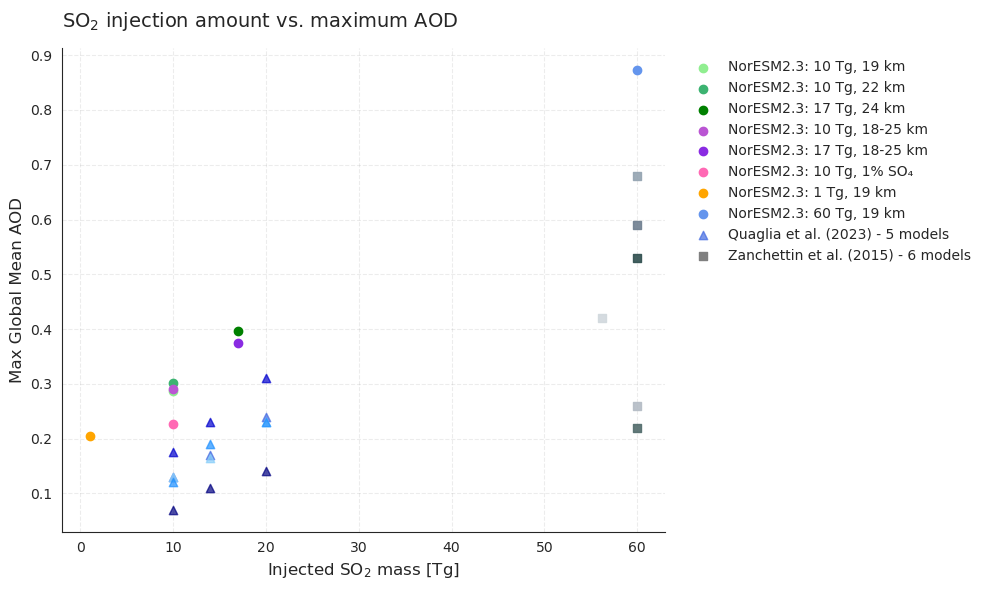

In [23]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(color="gray", alpha=0.15, linestyle="--", zorder=0)

# Own runs with NorESM2.3 (circles)
ax.scatter(10, aod_19_c_max, color="lightgreen", label="NorESM2.3: 10 Tg, 19 km", zorder=5)
ax.scatter(10, aod_22_max, color="mediumseagreen", label="NorESM2.3: 10 Tg, 22 km", zorder=5)
ax.scatter(17, aod_24_max, color="green", label="NorESM2.3: 17 Tg, 24 km", zorder=5)
ax.scatter(10, aod_1825_max, color="mediumorchid", label="NorESM2.3: 10 Tg, 18-25 km", zorder=5)
ax.scatter(17, aod_1825_17tg_max, color="blueviolet", label="NorESM2.3: 17 Tg, 18-25 km", zorder=5)
ax.scatter(10, aod_1pr_max, color="hotpink", label="NorESM2.3: 10 Tg, 1% SO₄", zorder=5)
ax.scatter(1, aod_1tg_max, color="orange", label="NorESM2.3: 1 Tg, 19 km", zorder=5)
ax.scatter(60, aod_60tg_max, color="cornflowerblue", label="NorESM2.3: 60 Tg, 19 km", zorder=5)

# Quaglia et al. 2023 (triangles)
quaglia_color = "lightsteelblue"
ax.scatter([10, 14, 20], [0.13, 0.17, 0.24], marker="^", color="royalblue", alpha=0.7, label="Quaglia et al. (2023) - 5 models")
ax.scatter([10, 14, 20], [0.13, 0.165, 0.23], marker="^", color="lightskyblue", alpha=0.7)
ax.scatter([10, 14, 20], [0.175, 0.23, 0.31], marker="^", color="mediumblue", alpha=0.7)
ax.scatter([10, 14, 20], [0.07, 0.11, 0.14], marker="^", color="navy", alpha=0.7)
ax.scatter([10, 14, 20], [0.12, 0.19, 0.23], marker="^", color="dodgerblue", alpha=0.7)

# Zanchettin et al. 2015 (squares) 
zanch_models = [
    {"x": 60,   "y": 0.53, "c": "#2f4f4f", "lab": "UM-UKCA"},     
    {"x": 60,   "y": 0.22, "c": "#526c6c", "lab": "SOCOL"},
    {"x": 60,   "y": 0.59, "c": "#708090", "lab": "MAECHAM"},   
    {"x": 60,   "y": 0.68, "c": "#94a3b1", "lab": "CESM-WACCM"},
    {"x": 60,   "y": 0.26, "c": "#b4bcc5", "lab": "M2D-UPMC"},
    {"x": 56.2, "y": 0.42, "c": "#d1d8dd", "lab": "EVA"}          
]

for m in zanch_models:
    ax.scatter(m["x"], m["y"], marker="s", color=m["c"], alpha=0.9)
ax.scatter([], [], marker="s", color="gray", label="Zanchettin et al. (2015) - 6 models")

ax.set_xlabel("Injected SO$_2$ mass [Tg]", fontsize=12)
ax.set_ylabel("Max Global Mean AOD", fontsize=12)
ax.set_title("SO$_2$ injection amount vs. maximum AOD", loc="left", fontsize=14, pad=15)

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
path_atm = "/nird/datapeak/NS1004K/elihho/NHIST_tropochem_250916/atm/hist"
ds_19 = xr.open_mfdataset(f"{path_atm}/NHIST_tropstratchem_f09_tn14_20250917_1975_2014.cam.h0.*.nc", combine="by_coords", parallel=True)

/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarn

In [25]:
shifted_time = np.array([shift_one_month_back(t) for t in ds_19['time'].values])
ds_19 = ds_19.assign_coords(time=shifted_time)

lat = ds_19["lat"]
weighted_lat = np.cos(np.deg2rad(lat))

In [26]:
temp_ctrl = ds_19["TREFHT"].weighted(weighted_lat).mean(dim = ["lat", "lon"]) -273.15
baseline = temp_ctrl.sel(time=slice("1976-01", "1990-12"))
base = baseline.groupby("time.month").mean("time")

In [27]:
temp_19_c = ds_19_c["TREFHT"].weighted(weighted_lat_19_c).mean(dim = ["lat", "lon"]) -273.15
t_anom_19_c = temp_19_c.groupby("time.month") - base
t_anom_19_c_max = min(t_anom_19_c)
t_anom_19_c_max.values

array(-0.2807754)

In [28]:
temp_60tg = ds_60tg["TREFHT"].weighted(weighted_lat_60tg).mean(dim = ["lat", "lon"]) -273.15
t_anom_60tg = temp_60tg.groupby("time.month") - base
t_anom_60tg_max = min(t_anom_60tg)
temp_22 = ds_22["TREFHT"].weighted(weighted_lat_22).mean(dim = ["lat", "lon"]) -273.15
t_anom_22 = temp_22.groupby("time.month") - base
t_anom_22max = min(t_anom_22)
temp_24 = ds_24["TREFHT"].weighted(weighted_lat_24).mean(dim = ["lat", "lon"]) -273.15
t_anom_24 = temp_24.groupby("time.month") - base
t_anom_24_max = min(t_anom_24)
temp_1825 = ds_1825["TREFHT"].weighted(weighted_lat_1825).mean(dim = ["lat", "lon"]) -273.15
t_anom_1825 = temp_1825.groupby("time.month") - base
t_anom_1825_max = min(t_anom_1825)
temp_1825_17tg = ds_1825_17tg["TREFHT"].weighted(weighted_lat_1825_17tg).mean(dim = ["lat", "lon"]) -273.15
t_anom_1825_17tg = temp_1825_17tg.groupby("time.month") - base
t_anom_1825_17tg_max = min(t_anom_1825_17tg)
temp_1tg = ds_1tg["TREFHT"].weighted(weighted_lat_1tg).mean(dim = ["lat", "lon"]) -273.15
t_anom_1tg = temp_1tg.groupby("time.month") - base
t_anom_1tg_max = min(t_anom_1tg)
temp_1pr = ds_1pr["TREFHT"].weighted(weighted_lat_1pr).mean(dim = ["lat", "lon"]) -273.15
t_anom_1pr = temp_1pr.groupby("time.month") - base
t_anom_1pr_max = min(t_anom_1pr)

<>:15: SyntaxWarning: invalid escape sequence '\c'
<>:15: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_2503203/2252861692.py:15: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel("Largest temp. anomaly [$^\circ$C]", fontsize=12)


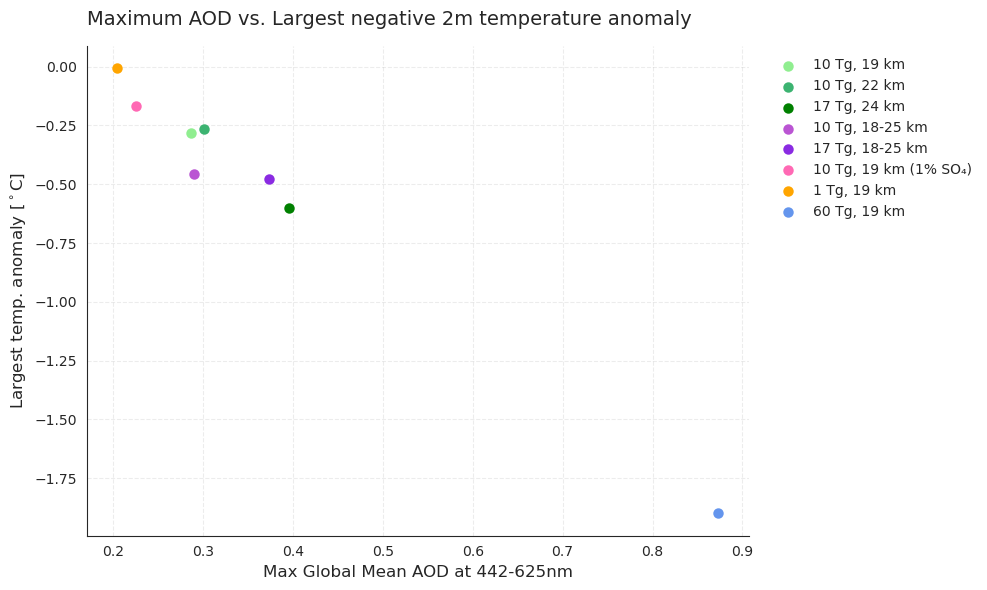

In [29]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(color="gray", alpha=0.15, linestyle="--", zorder=0)

ax.scatter(aod_19_c_max, t_anom_19_c_max, color="lightgreen", lw=1.5,label="10 Tg, 19 km")
ax.scatter(aod_22_max, t_anom_22max,color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
ax.scatter(aod_24_max, t_anom_24_max,color="green", lw=1.5,label="17 Tg, 24 km")
ax.scatter(aod_1825_max, t_anom_1825_max,color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
ax.scatter(aod_1825_17tg_max, t_anom_1825_17tg_max,color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
ax.scatter(aod_1pr_max, t_anom_1pr_max,color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
ax.scatter(aod_1tg_max, t_anom_1tg_max, color="orange", lw=1.5, label="1 Tg, 19 km")
ax.scatter(aod_60tg_max, t_anom_60tg_max,color="cornflowerblue", lw=1.5,label="60 Tg, 19 km ")

ax.set_xlabel("Max Global Mean AOD at 442-625nm", fontsize=12)
ax.set_ylabel("Largest temp. anomaly [$^\circ$C]", fontsize=12)
ax.set_title("Maximum AOD vs. Largest negative 2m temperature anomaly", loc="left", fontsize=14, pad=15)

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\c'
<>:10: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_2503203/3335678083.py:10: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel("Largest abs. temp. anomaly [$^\circ$C]")


Text(0.5, 1.0, 'Max 2m temp anomaly vs. max AOD')

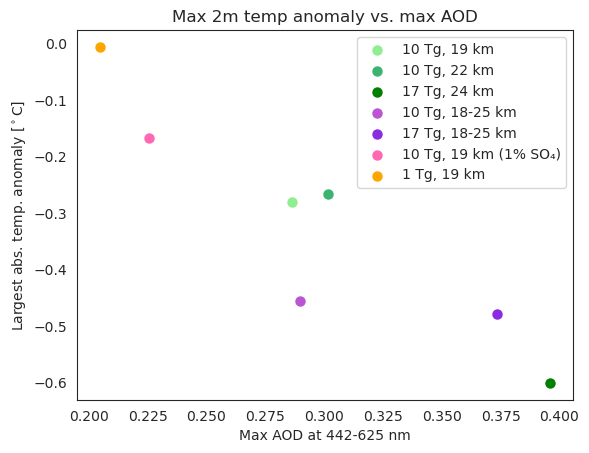

In [30]:
plt.scatter(aod_19_c_max, t_anom_19_c_max, color="lightgreen", lw=1.5,label="10 Tg, 19 km")
plt.scatter(aod_22_max, t_anom_22max,color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
plt.scatter(aod_24_max, t_anom_24_max,color="green", lw=1.5,label="17 Tg, 24 km")
plt.scatter(aod_1825_max, t_anom_1825_max,color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
plt.scatter(aod_1825_17tg_max, t_anom_1825_17tg_max,color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
plt.scatter(aod_1pr_max, t_anom_1pr_max,color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
plt.scatter(aod_1tg_max, t_anom_1tg_max, color="orange", lw=1.5, label="1 Tg, 19 km")

plt.xlabel("Max AOD at 442-625 nm")
plt.ylabel("Largest abs. temp. anomaly [$^\circ$C]")
plt.legend()
plt.title("Max 2m temp anomaly vs. max AOD")

<>:23: SyntaxWarning: invalid escape sequence '\c'
<>:23: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_2503203/2200690579.py:23: SyntaxWarning: invalid escape sequence '\c'
  ax[1].set_ylabel("Max temperature amomaly [$^\circ$C]")


Text(0.5, 0.98, 'Scatterplots for comparing SO$_2$, AOD, and temperautre anomalies')

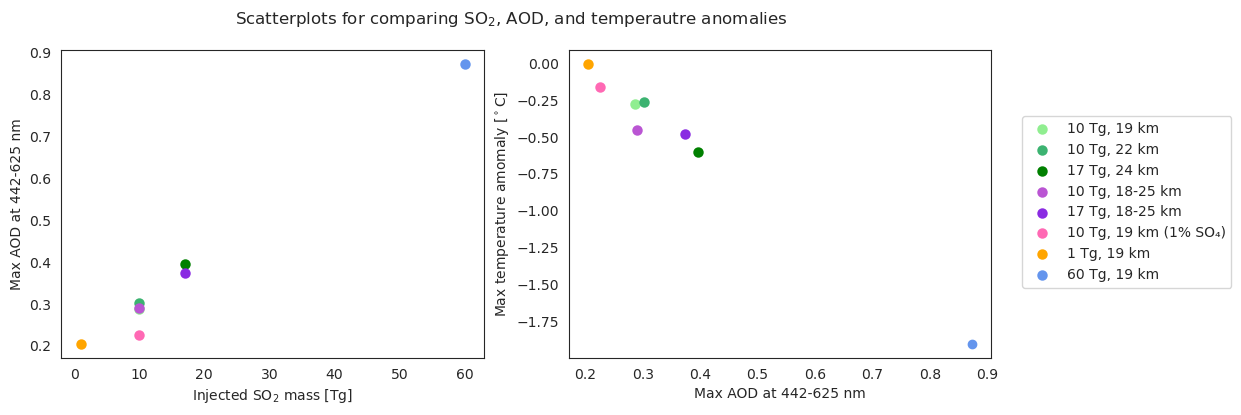

In [31]:
fig, ax = plt.subplots(1,2, figsize=(12, 4), sharex=False)

ax[0].scatter(10, aod_19_c_max, color="lightgreen", lw=1.5,label="10 Tg, 19 km")
ax[0].scatter(10, aod_22_max,color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
ax[0].scatter(17, aod_24_max,color="green", lw=1.5,label="17 Tg, 24 km")
ax[0].scatter(10, aod_1825_max,color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
ax[0].scatter(17, aod_1825_17tg_max,color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
ax[0].scatter(10, aod_1pr_max,color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
ax[0].scatter(1, aod_1tg_max, color="orange", lw=1.5, label="1 Tg, 19 km")
ax[0].scatter(60, aod_60tg_max,color="cornflowerblue", lw=1.5,label="60 Tg, 19 km ")
ax[0].set_xlabel("Injected SO$_2$ mass [Tg]")
ax[0].set_ylabel("Max AOD at 442-625 nm")

ax[1].scatter(aod_19_c_max, t_anom_19_c_max, color="lightgreen", lw=1.5) #,label="10 Tg, 19 km")
ax[1].scatter(aod_22_max, t_anom_22max,color="mediumseagreen", lw=1.5) #,label="10 Tg, 22 km")
ax[1].scatter(aod_24_max, t_anom_24_max,color="green", lw=1.5) #,label="17 Tg, 24 km")
ax[1].scatter(aod_1825_max, t_anom_1825_max,color="mediumorchid", lw=1.5) #,label="10 Tg, 18-25 km")
ax[1].scatter(aod_1825_17tg_max, t_anom_1825_17tg_max,color="blueviolet", lw=1.5) #,label="17 Tg, 18-25 km")
ax[1].scatter(aod_1pr_max, t_anom_1pr_max,color="hotpink", lw=1.5) #, label="10 Tg, 19 km (1% SO₄)")
ax[1].scatter(aod_1tg_max, t_anom_1tg_max, color="orange", lw=1.5) #, label="1 Tg, 19 km")
ax[1].scatter(aod_60tg_max, t_anom_60tg_max,color="cornflowerblue") #, lw=1.5,label="60 Tg, 19 km ")
ax[1].set_xlabel("Max AOD at 442-625 nm")
ax[1].set_ylabel("Max temperature amomaly [$^\circ$C]")

fig.legend(
    loc="center left",
    bbox_to_anchor=(0.92, 0.5),
    frameon=True
)
#plt.tight_layout
plt.suptitle("Scatterplots for comparing SO$_2$, AOD, and temperautre anomalies")

In [32]:
lat_19 = ds_19["lat"]
weighted_lat_19 = np.cos(np.deg2rad(lat_19))

In [33]:
tropopause_19 = ds_19["TROP_P"].weighted(weighted_lat_19).mean(dim=["lat", "lon"])
p_lev_19 = tropopause_19 * 0.01
tropopause_19_c = ds_19_c["TROP_P"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
p_lev_19_c = tropopause_19_c * 0.01
tropopause_22 = ds_22["TROP_P"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
p_lev_22 = tropopause_22 * 0.01
tropopause_24 = ds_24["TROP_P"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
p_lev_24 = tropopause_24 * 0.01
tropopause_1825 = ds_1825["TROP_P"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
p_lev_1825 = tropopause_1825 * 0.01
tropopause_1825_17tg = ds_1825_17tg["TROP_P"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
p_lev_1825_17tg = tropopause_1825_17tg * 0.01
tropopause_1tg = ds_1tg["TROP_P"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
p_lev_1tg = tropopause_1tg * 0.01
tropopause_1pr = ds_1pr["TROP_P"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
p_lev_1pr = tropopause_1pr * 0.01
tropopause_60tg = ds_60tg["TROP_P"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
p_lev_60tg = tropopause_60tg * 0.01

In [60]:
cm_to_mym = 10000
def get_reff_max(ds, p_tropo):
    lev_diff = np.gradient(ds.lev.values)
    weights_lev = xr.DataArray(lev_diff, coords={'lev': ds.lev}, dims=['lev'])
    
    weights_lat = np.cos(np.deg2rad(ds.lat))
    total_weight = weights_lev * weights_lat
    
    reff_strat = ds.REFF_AERO.where((ds.lev >= 3.64) & (ds.lev <= p_tropo))
    
    ts = reff_strat.weighted(total_weight).mean(dim=["lev", "lat", "lon"])
    
    return float(ts.max()) * cm_to_mym

reff_60 = get_reff_max(ds_60tg, p_lev_60tg)
reff_19 = get_reff_max(ds_19_c, p_lev_19_c)

print(f"60 Tg: {reff_60:.4f}")
print(f"19 km: {reff_19:.4f}")

60 Tg: 0.1597
19 km: 0.1523


In [61]:
datasets = [ds_19_c, ds_60tg, ds_22, ds_24, ds_1825, ds_1825_17tg, ds_1tg, ds_1pr]
p_levels = [p_lev_19_c, p_lev_60tg, p_lev_22, p_lev_24, p_lev_1825, p_lev_1825_17tg, p_lev_1tg, p_lev_1pr]

reff_max_values = []

for d, p in zip(datasets, p_levels):
    reff_series = get_reff_max(d, p)
    reff_max_values.append(reff_series)

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2503203/1316225654.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("Max R$_{eff}$ [$\mu$m]", fontsize=12)


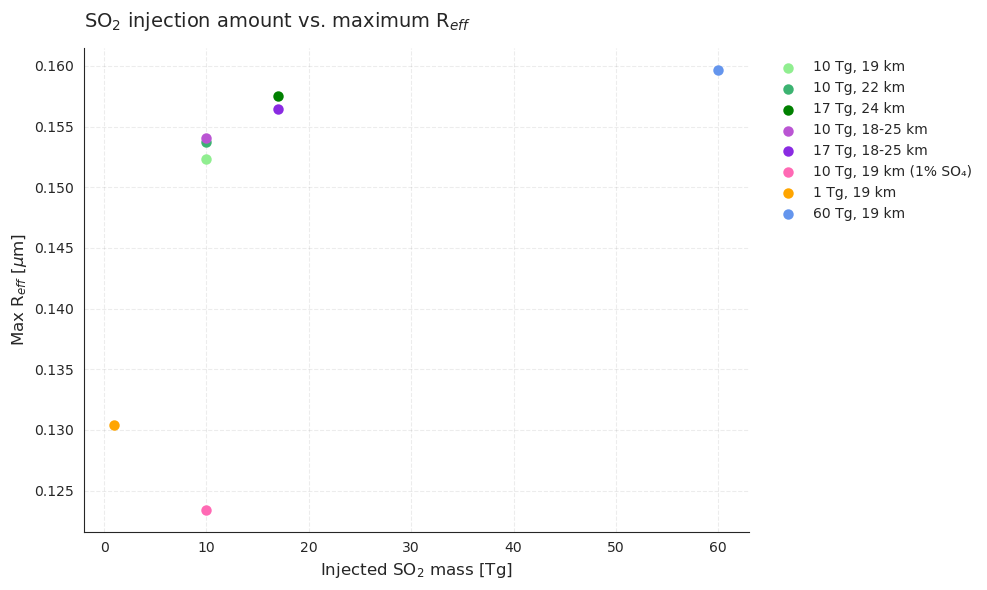

In [62]:
cm_to_mym = 10000

sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(color="gray", alpha=0.15, linestyle="--", zorder=0)
ax.scatter(10, reff_max_values[0], color="lightgreen", lw=1.5,label="10 Tg, 19 km")
ax.scatter(10, reff_max_values[2],color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
ax.scatter(17, reff_max_values[3],color="green", lw=1.5,label="17 Tg, 24 km")
ax.scatter(10, reff_max_values[4],color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
ax.scatter(17, reff_max_values[5],color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
ax.scatter(10, reff_max_values[7],color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
ax.scatter(1, reff_max_values[6], color="orange", lw=1.5, label="1 Tg, 19 km")
ax.scatter(60, reff_max_values[1],color="cornflowerblue", lw=1.5,label="60 Tg, 19 km ")

ax.set_xlabel("Injected SO$_2$ mass [Tg]", fontsize=12)
ax.set_ylabel("Max R$_{eff}$ [$\mu$m]", fontsize=12)
ax.set_title("SO$_2$ injection amount vs. maximum R$_{eff}$ ", loc="left", fontsize=14, pad=15)

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2503203/3366994314.py:14: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("Max R$_{eff}$ [$\mu$m]", fontsize=12)


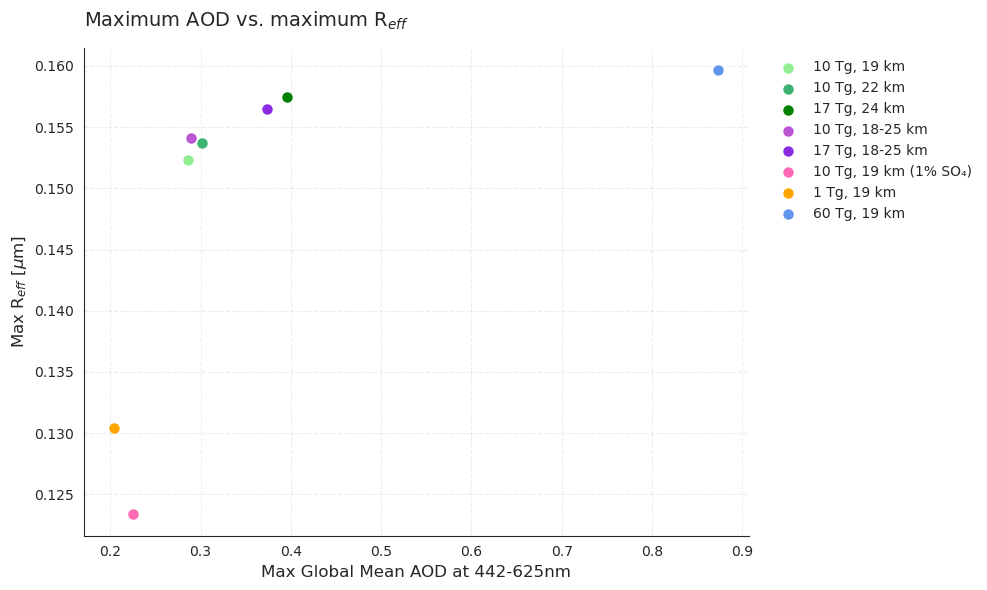

In [64]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(color="gray", alpha=0.15, linestyle="--", zorder=0)
plt.scatter(aod_19_c_max, reff_max_values[0], color="lightgreen", lw=1.5,label="10 Tg, 19 km")
plt.scatter(aod_22_max, reff_max_values[2],color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
plt.scatter(aod_24_max, reff_max_values[3],color="green", lw=1.5,label="17 Tg, 24 km")
plt.scatter(aod_1825_max, reff_max_values[4],color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
plt.scatter(aod_1825_17tg_max, reff_max_values[5],color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
plt.scatter(aod_1pr_max, reff_max_values[7],color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
plt.scatter(aod_1tg_max, reff_max_values[6], color="orange", lw=1.5, label="1 Tg, 19 km")
plt.scatter(aod_60tg_max, reff_max_values[1],color="cornflowerblue", lw=1.5,label="60 Tg, 19 km ")

ax.set_xlabel("Max Global Mean AOD at 442-625nm", fontsize=12)
ax.set_ylabel("Max R$_{eff}$ [$\mu$m]", fontsize=12)
ax.set_title("Maximum AOD vs. maximum R$_{eff}$ ", loc="left", fontsize=14, pad=15)

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2503203/651964837.py:13: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("Max R$_{eff}$ [$\mu$m]", fontsize=12)


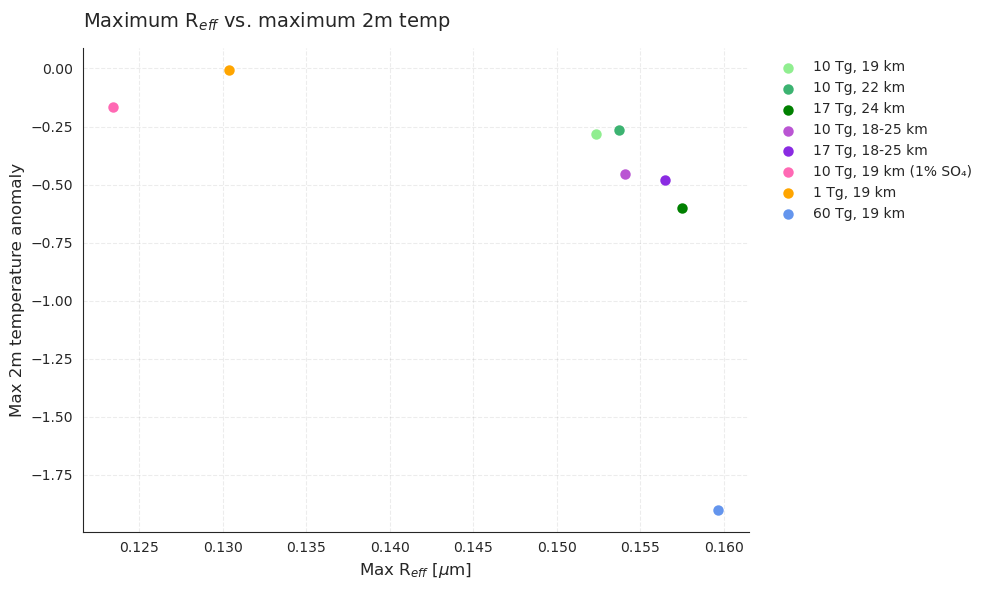

In [67]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(color="gray", alpha=0.15, linestyle="--", zorder=0)
plt.scatter(reff_max_values[0], t_anom_19_c_max, color="lightgreen", lw=1.5,label="10 Tg, 19 km")
plt.scatter(reff_max_values[2], t_anom_22max, color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
plt.scatter(reff_max_values[3], t_anom_24_max, color="green", lw=1.5,label="17 Tg, 24 km")
plt.scatter(reff_max_values[4], t_anom_1825_max, color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
plt.scatter(reff_max_values[5], t_anom_1825_17tg_max, color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
plt.scatter(reff_max_values[7], t_anom_1pr_max, color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
plt.scatter(reff_max_values[6], t_anom_1tg_max, color="orange", lw=1.5, label="1 Tg, 19 km")
plt.scatter(reff_max_values[1], t_anom_60tg_max, color="cornflowerblue", lw=1.5,label="60 Tg, 19 km ")

ax.set_xlabel("Max R$_{eff}$ [$\mu$m]", fontsize=12)
ax.set_ylabel("Max 2m temperature anomaly", fontsize=12)
ax.set_title("Maximum R$_{eff}$ vs. maximum 2m temp", loc="left", fontsize=14, pad=15)

ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

sns.despine()
plt.tight_layout()
plt.show()